
--- Feature Removal Plot for Clear Weather ---


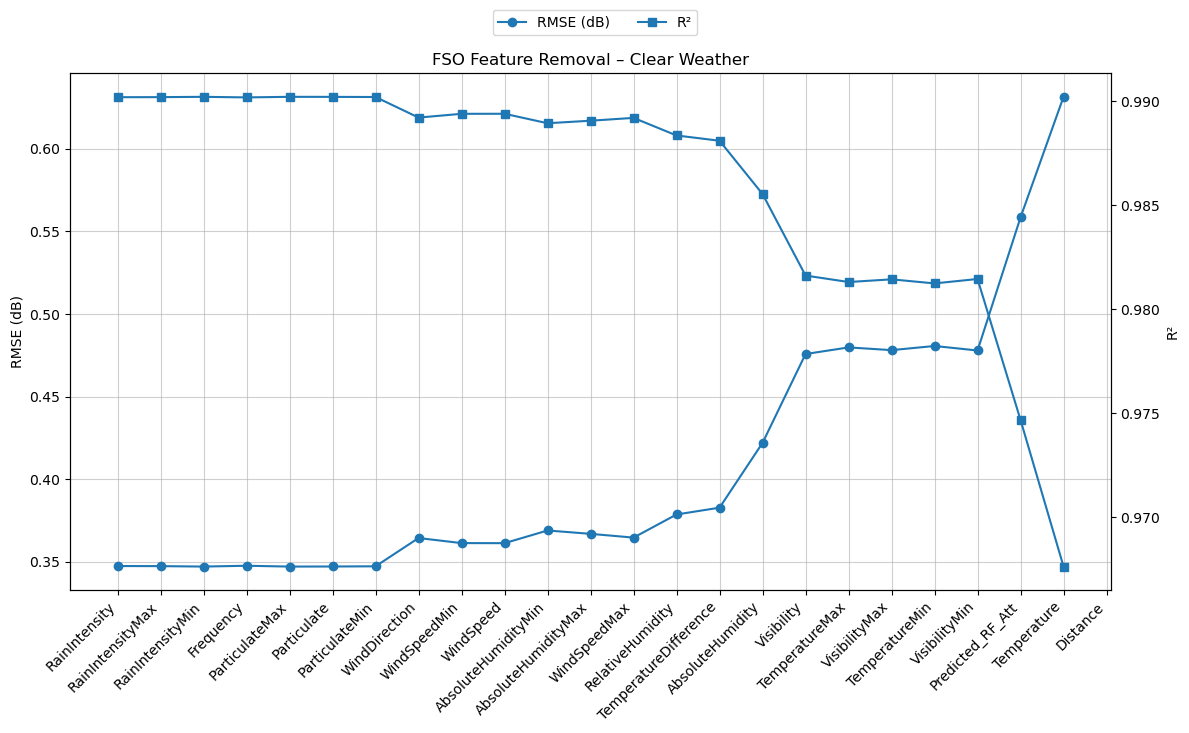


--- Feature Removal Plot for Duststorm ---


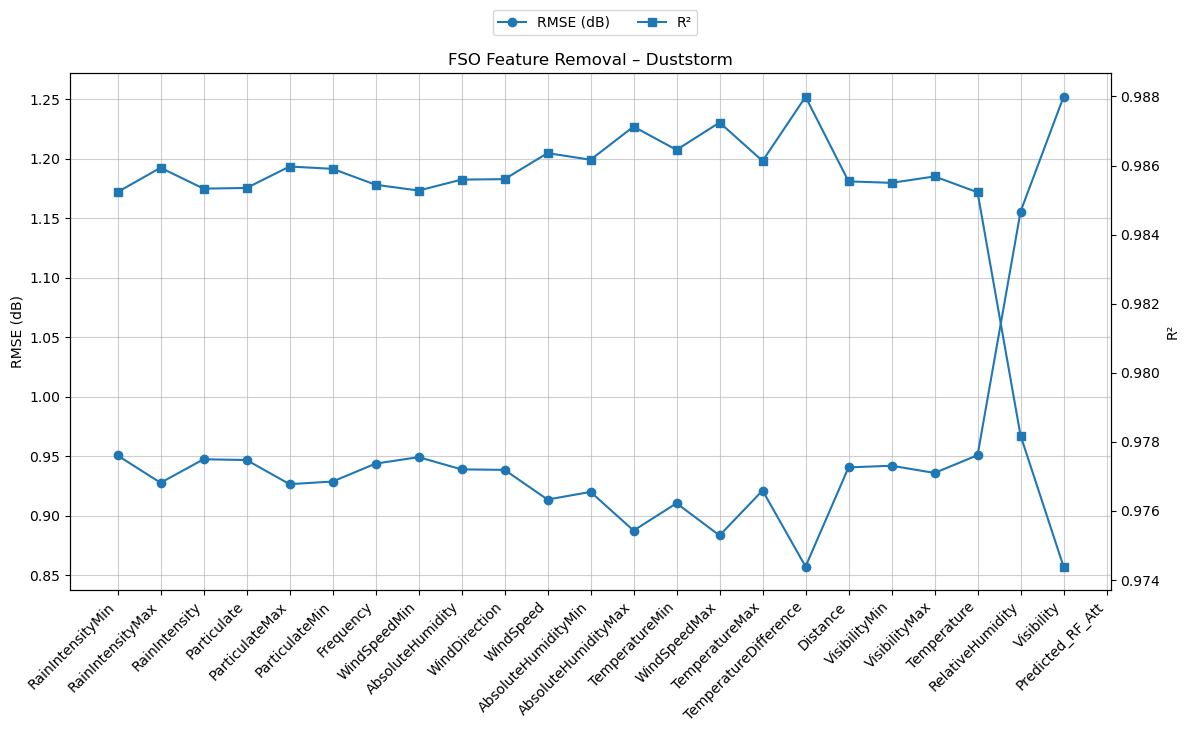


--- Feature Removal Plot for Fog ---


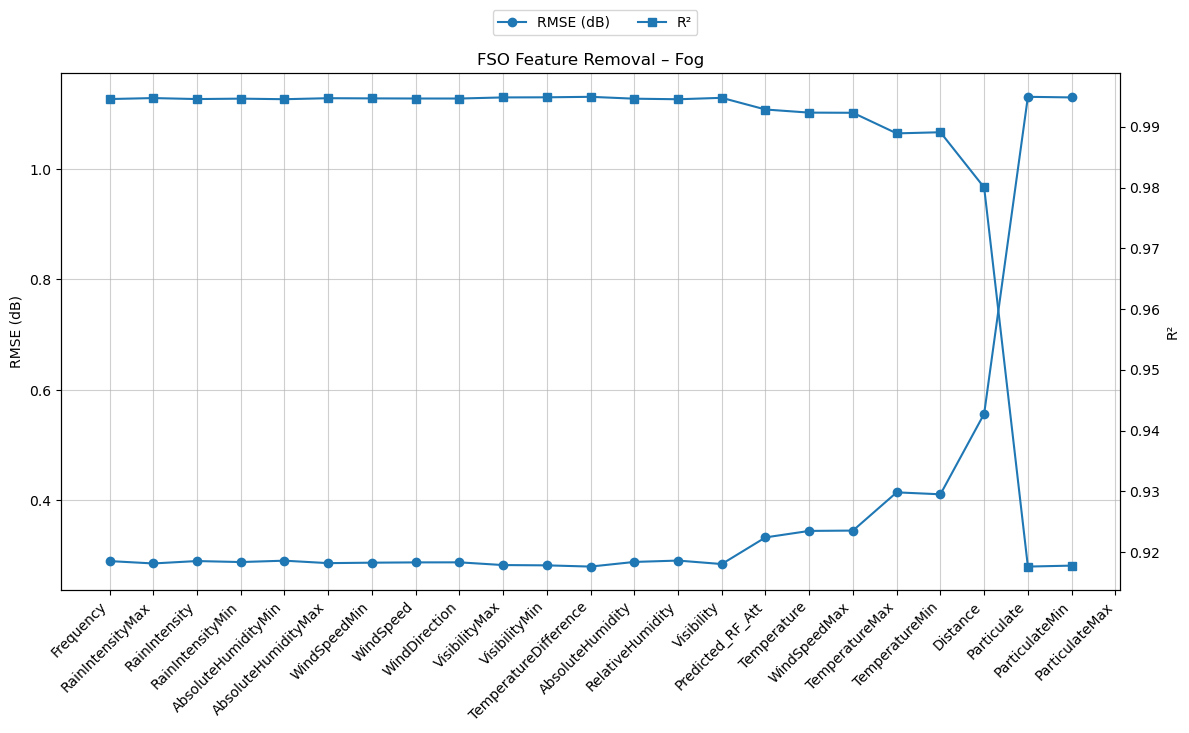


--- Feature Removal Plot for Drizzle ---


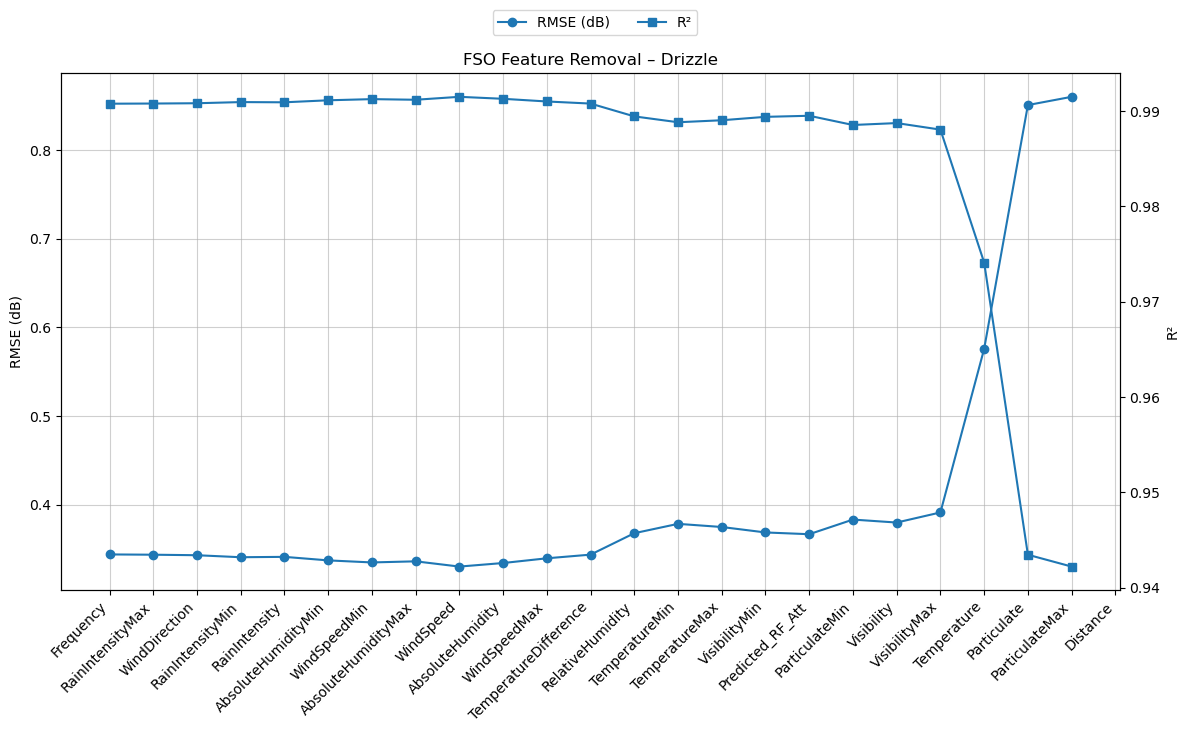


--- Feature Removal Plot for Rain ---


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# 0. 读取数据
data = pd.read_csv("RFLFSODataFull.csv")  # 换成你的路径

# 0.1 基础映射
weather_mapping = {
    0: 'Clear Weather',
    3: 'Duststorm',
    4: 'Fog',
    5: 'Drizzle',
    6: 'Rain',
    7: 'Snow',
    8: 'Showers'
}
rf_features_mapping = {
    0: ['Frequency','Temperature','AbsoluteHumidityMax','AbsoluteHumidityMin','AbsoluteHumidity','Distance'],
    3: ['Temperature','AbsoluteHumidityMin'],
    4: ['RainIntensity','AbsoluteHumidityMin','RelativeHumidity'],
    5: ['Distance','RainIntensity','RainIntensityMax','AbsoluteHumidityMax','AbsoluteHumidityMin','AbsoluteHumidity'],
    6: ['Distance','Temperature','RainIntensityMax','RainIntensityMin','AbsoluteHumidity','RainIntensity'],
    7: ['RainIntensityMin','WindSpeedMax','TemperatureDifference'],
    8: ['Frequency','Distance','Particulate','ParticulateMax','Visibility','VisibilityMax','VisibilityMin',
        'ParticulateMin','RainIntensityMax','RainIntensityMin','RainIntensity',
        'AbsoluteHumidityMax','AbsoluteHumidity','AbsoluteHumidityMin']
}
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4]
}

# 1. 专门只做画图的函数
def feature_removal_analysis(X, y, model, title):
    model.fit(X, y)
    importances = model.feature_importances_
    feats = np.array(X.columns)
    sorted_idx = np.argsort(importances)[::-1]
    sorted_feats = feats[sorted_idx]

    rmse_scores = []
    r2_scores   = []
    for i in range(len(sorted_feats), 1, -1):
        sel = sorted_feats[:i]
        model.fit(X[sel], y)
        y_pred = model.predict(X[sel])
        rmse_scores.append(np.sqrt(mean_squared_error(y, y_pred)))
        r2_scores.append(r2_score(y, y_pred))

    # 画图，legend 放到正上方
    fig, ax1 = plt.subplots(figsize=(12,7))
    ln1 = ax1.plot(range(len(rmse_scores)), rmse_scores, marker='o', label='RMSE (dB)')
    ax1.set_ylabel('RMSE (dB)')
    ax1.grid(alpha=0.6)

    ax2 = ax1.twinx()
    ln2 = ax2.plot(range(len(r2_scores)), r2_scores, marker='s', linestyle='-', label='R²')
    ax2.set_ylabel('R²')

    ax1.set_xticks(range(len(sorted_feats)))
    ax1.set_xticklabels(sorted_feats[::-1], rotation=45, ha='right')

    # 把两条线的 legend 放到顶部中央
    lns = ln1 + ln2
    labels = [l.get_label() for l in lns]
    fig.legend(lns, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.05))

    plt.title(title)
    plt.tight_layout()
    plt.show()

    return sorted_feats, rmse_scores, r2_scores

# 2. 第一轮：遍历每种天气，只做画图
for code, label in weather_mapping.items():
    subset = data[data['SYNOPCode'] == code]
    if len(subset) < 10:
        continue

    print(f"\n--- Feature Removal Plot for {label} ---")
    # RF 子模型预测，为 FSO 做输入
    X = subset.drop(['RFL_Att','FSO_Att'], axis=1)
    y_rf  = subset['RFL_Att']
    y_fso = subset['FSO_Att']

    X_train, _, y_rf_train, _, y_fso_train, _ = train_test_split(
        X, y_rf, y_fso, test_size=0.2, random_state=42)

    rf_feats = rf_features_mapping[code]
    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(X_train[rf_feats], y_rf_train)
    rf_pred = rf.predict(X_train[rf_feats])

    X_fso_in = X_train.drop(columns=['Time','SYNOPCode']).copy()
    X_fso_in['Predicted_RF_Att'] = rf_pred

    feature_removal_analysis(
        X_fso_in, y_fso_train,
        RandomForestRegressor(random_state=42),
        f"FSO Feature Removal – {label}"
    )



In [ ]:
# 4. 第二轮：手动定义特征并训练评估，记录 fso_feats_map
fso_feats_map = {}

results = []
for code, label in weather_mapping.items():
    subset = data[data['SYNOPCode'] == code]
    if len(subset) < 10:
        continue
    X = subset.drop(['RFL_Att','FSO_Att'], axis=1)
    y_rf  = subset['RFL_Att']
    y_fso = subset['FSO_Att']
    X_train, X_test, y_rf_train, y_rf_test, y_fso_train, y_fso_test = train_test_split(
        X, y_rf, y_fso, test_size=0.2, random_state=42)
    # RF
    rf_search = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_dist,
                                   n_iter=5, cv=2, scoring='neg_mean_squared_error',
                                   n_jobs=-1, random_state=42)
    rf_search.fit(X_train[rf_features_mapping[code]], y_rf_train)
    best_rf = rf_search.best_estimator_
    # 构建 FSO 输入
    rf_pred_train = best_rf.predict(X_train[rf_features_mapping[code]])
    X_fso_in_train = X_train.drop(columns=['Time','SYNOPCode']).copy()
    X_fso_in_train['Predicted_RF_Att'] = rf_pred_train
    # 手动定义保留特征
    if code == 0:
        feats = ['Frequency', 'Distance', 'AbsoluteHumidity', 'Temperature', 'Predicted_RF_Att']
    elif code == 3:
        feats = ['Temperature', 'AbsoluteHumidityMin', 'Predicted_RF_Att']
    elif code == 4:
        feats = ['RainIntensity', 'RelativeHumidity', 'AbsoluteHumidityMin', 'Predicted_RF_Att']
    elif code == 5:
        feats = ['Distance', 'RainIntensity', 'AbsoluteHumidity', 'Predicted_RF_Att']
    elif code == 6:
        feats = ['Distance', 'RainIntensityMax', 'Temperature', 'Predicted_RF_Att']
    elif code == 7:
        feats = ['RainIntensityMin', 'WindSpeedMax', 'TemperatureDifference', 'Predicted_RF_Att']
    else:
        feats = ['Frequency', 'Particulate', 'Visibility', 'AbsoluteHumidity', 'RainIntensity', 'Predicted_RF_Att']
    fso_feats_map[code] = feats
    X_train_fso = X_fso_in_train[feats]
    # FSO 搜索
    fso_search = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_dist,
                                    n_iter=5, cv=2, scoring='neg_mean_squared_error',
                                    n_jobs=-1, random_state=42)
    fso_search.fit(X_train_fso, y_fso_train)
    best_fso = fso_search.best_estimator_
    # 测试集预测
    rf_test_pred = best_rf.predict(X_test[rf_features_mapping[code]])
    X_fso_in_test = X_test.drop(columns=['Time','SYNOPCode']).copy()
    X_fso_in_test['Predicted_RF_Att'] = rf_test_pred
    fso_test_pred = best_fso.predict(X_fso_in_test[feats])
    # 记录结果
    results.append({
        'Weather': label,
        'RF RMSE': mean_squared_error(y_rf_test, rf_test_pred, squared=False),
        'RF R²':   r2_score(y_rf_test, rf_test_pred),
        'FSO RMSE': mean_squared_error(y_fso_test, fso_test_pred, squared=False),
        'FSO R²':   r2_score(y_fso_test, fso_test_pred),
        'Pearson Corr (Real)': pearsonr(y_rf_test, y_fso_test)[0],
        'Pearson Corr (Pred)': pearsonr(rf_test_pred, fso_test_pred)[0],
        'Mutual Info (Real)': mutual_info_regression(y_rf_test.values.reshape(-1,1), y_fso_test)[0] / np.log(len(y_rf_test)),
        'Mutual Info (Pred)': mutual_info_regression(rf_test_pred.reshape(-1,1), fso_test_pred)[0] / np.log(len(rf_test_pred))
    })

# 5. 汇总并可视化相关性对比
results_df = pd.DataFrame(results)
print("\n=== Final Results ===")
print(results_df)
fig, ax = plt.subplots(figsize=(10,5))
width = 0.35
x = np.arange(len(results_df))
ax.bar(x-width/2, results_df['Pearson Corr (Real)'], width, label='Real')
ax.bar(x+width/2, results_df['Pearson Corr (Pred)'], width, label='Pred')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Weather'], rotation=45)
ax.set_ylabel('Pearson Corr')
plt.title('Real vs. Predicted Pearson Correlation by Weather')
plt.legend()
plt.tight_layout()
plt.show()

# 6. 热力图绘制：使用第二轮确定的特征列表
for code, label in weather_mapping.items():
    subset = data[data['SYNOPCode'] == code]
    if len(subset) < 10:
        print(f"Skipping {label}, sample too small.")
        continue
    print(f"Heatmaps for {label}, samples: {len(subset)}")
    # 分 train/test
    X_sub = subset.drop(['RFL_Att','FSO_Att'], axis=1)
    y_rf_sub  = subset['RFL_Att']
    y_fso_sub = subset['FSO_Att']
    X_train_sub, X_test_sub, y_rf_train_sub, y_rf_test_sub, y_fso_train_sub, y_fso_test_sub = \
        train_test_split(X_sub, y_rf_sub, y_fso_sub, test_size=0.2, random_state=42)
    # RF 简易训练
    rf_feats = rf_features_mapping[code]
    rf_heat = RandomForestRegressor(random_state=42)
    rf_heat.fit(X_train_sub[rf_feats], y_rf_train_sub)
    rf_test_pred_sub = rf_heat.predict(X_test_sub[rf_feats])
    # FSO 输入
    feats = fso_feats_map[code]
    X_fso_in_sub = X_train_sub.drop(columns=['Time','SYNOPCode']).copy()
    X_fso_in_sub['Predicted_RF_Att'] = rf_heat.predict(X_train_sub[rf_feats])
    X_train_fso_sub = X_fso_in_sub[feats]
    X_fso_test_in = X_test_sub.drop(columns=['Time','SYNOPCode']).copy()
    X_fso_test_in['Predicted_RF_Att'] = rf_test_pred_sub
    X_test_fso_sub = X_fso_test_in[feats]
    fso_heat = RandomForestRegressor(random_state=42)
    fso_heat.fit(X_train_fso_sub, y_fso_train_sub)
    fso_test_pred_sub = fso_heat.predict(X_test_fso_sub)
    # 画热力图
    fig, axs = plt.subplots(1,2, figsize=(12,5))
    h1 = axs[0].hist2d(y_rf_test_sub, y_fso_test_sub, bins=20, cmap='viridis')
    axs[0].set_title(f"{label} - Measured")
    axs[0].set_xlabel('Measured RF Att')
    axs[0].set_ylabel('Measured FSO Att')
    fig.colorbar(h1[3], ax=axs[0], label='Count')
    h2 = axs[1].hist2d(rf_test_pred_sub, fso_test_pred_sub, bins=20, cmap='plasma')
    axs[1].set_title(f"{label} - Predicted")
    axs[1].set_xlabel('Predicted RF Att')
    axs[1].set_ylabel('Predicted FSO Att')
    fig.colorbar(h2[3], ax=axs[1], label='Count')
    plt.tight_layout()
    plt.show()

# 7. ALL weather 合并热力图
print("Heatmaps for ALL weather combined.")
all = data.copy()
X_all = all.drop(['RFL_Att','FSO_Att'], axis=1)
y_rf_all  = all['RFL_Att']
y_fso_all = all['FSO_Att']
Xtr, Xte, y_rf_tr_all, y_rf_te_all, y_fso_tr_all, y_fso_te_all = \
    train_test_split(X_all, y_rf_all, y_fso_all, test_size=0.2, random_state=42)
rf_all = RandomForestRegressor(random_state=42)
rf_all.fit(Xtr.drop(columns=['Time','SYNOPCode']), y_rf_tr_all)
rf_pred_all = rf_all.predict(Xte.drop(columns=['Time','SYNOPCode']))
# 全部合并特征
feats_all = list(Xtr.drop(columns=['Time','SYNOPCode']).columns) + ['Predicted_RF_Att']
Xtr_fso_all = Xtr.drop(columns=['Time','SYNOPCode']).copy()
Xtr_fso_all['Predicted_RF_Att'] = rf_all.predict(Xtr.drop(columns=['Time','SYNOPCode']))
Xte_fso_all = Xte.drop(columns=['Time','SYNOPCode']).copy()
Xte_fso_all['Predicted_RF_Att'] = rf_pred_all
fso_all = RandomForestRegressor(random_state=42)
fso_all.fit(Xtr_fso_all[feats_all], y_fso_tr_all)
fso_pred_all = fso_all.predict(Xte_fso_all[feats_all])
fig, axs = plt.subplots(1,2, figsize=(12,5))
h1a = axs[0].hist2d(y_rf_te_all, y_fso_te_all, bins=20, cmap='viridis')
axs[0].set_title('ALL - Measured')
axs[0].set_xlabel('Measured RF Att')
axs[0].set_ylabel('Measured FSO Att')
fig.colorbar(h1a[3], ax=axs[0], label='Count')
h2a = axs[1].hist2d(rf_pred_all, fso_pred_all, bins=20, cmap='plasma')
axs[1].set_title('ALL - Predicted')
axs[1].set_xlabel('Predicted RF Att')
axs[1].set_ylabel('Predicted FSO Att')
fig.colorbar(h2a[3], ax=axs[1], label='Count')
plt.tight_layout()
plt.show()


In [ ]:
# 4. 第二轮：手动输入 + 变量赋值
results = []
for code, label in weather_mapping.items():
    subset = data[data['SYNOPCode'] == code]
    if len(subset) < 10:
        continue

    X = subset.drop(['RFL_Att','FSO_Att'], axis=1)
    y_rf  = subset['RFL_Att']
    y_fso = subset['FSO_Att']
    X_train, X_test, y_rf_train, y_rf_test, y_fso_train, y_fso_test = train_test_split(
        X, y_rf, y_fso, test_size=0.2, random_state=42)

    # RF 部分
    rf_search = RandomizedSearchCV(
        RandomForestRegressor(random_state=42), param_dist,
        n_iter=5, cv=2, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42
    )
    rf_search.fit(X_train[rf_features_mapping[code]], y_rf_train)
    best_rf = rf_search.best_estimator_

    # 构建 FSO 输入
    rf_pred_train = best_rf.predict(X_train[rf_features_mapping[code]])
    X_fso_in_train = X_train.drop(columns=['Time','SYNOPCode']).copy()
    X_fso_in_train['Predicted_RF_Att'] = rf_pred_train

    # 手动定义保留特征，并直接赋给变量
    if code == 0:  # Clear Weather
        X_selected_fso_clear = X_fso_in_train[[
            'Distance', 'Temperature', 'Predicted_RF_Att', 'VisibilityMin', 'TemperatureMin', 'VisibilityMax', 'TemperatureMax', 'Visibility'
        ]]
    elif code == 3:  # Duststorm
        X_selected_fso_duststorm = X_fso_in_train[[
            'Temperature', 'Predicted_RF_Att', 'RelativeHumidity', 'Visibility', 'VisibilityMax', 'VisibilityMin'
        ]]
    elif code == 4:  # Fog
        X_selected_fso_fog = X_fso_in_train[[
            'ParticulateMax', 'ParticulateMin', 'Particulate', 'Distance', 'TemperatureMin', 'TemperatureMax', 'WindSpeedMax', 'Temperature', 'Predicted_RF_Att'
        ]]
    elif code == 5:  # Drizzle
        X_selected_fso_drizzle = X_fso_in_train[[
            'Distance', 'ParticulateMax', 'Particulate', 'Temperature', 'VisibilityMax', 'Visibility', 'ParticulateMin', 'Predicted_RF_Att'
        ]]
    elif code == 6:  # Rain
        X_selected_fso_rain = X_fso_in_train[[
            'Distance', 'Particulate', 'ParticulateMax', 'ParticulateMin', 'Predicted_RF_Att', 'Temperature', 'RelativeHumidity', 'Visibility', 'VisibilityMax'
        ]]
    elif code == 7:  # Snow
        X_selected_fso_snow = X_fso_in_train[[
            'Particulate', 'ParticulateMin', 'ParticulateMax', 'TemperatureDifference', 'Predicted_RF_Att'
        ]]
    else:  # Showers (code 8)
        X_selected_fso_showers = X_fso_in_train[[
            'Distance', 'Visibility', 'VisibilityMin', 'VisibilityMax', 'RelativeHumidity', 'Temperature', 'AbsoluteHumidity', 'Predicted_RF_Att', 'Particulate', 'AbsoluteHumidityMax', 'AbsoluteHumidityMin', 'ParticulateMin'
        ]]

    # 根据变量名获取特征列表
    var_name = f"X_selected_fso_{label.lower().replace(' ','')}"
    fso_feats = list(locals()[var_name].columns)

    # 7. 对比 “真实 vs. 预测” 的相关性
    # 7.1 计算独立评价指标
    rf_test_pred = best_rf.predict(X_test[rf_features_mapping[code]])
    fso_train = locals()[var_name]

    # FSO 部分超参搜索
    fso_search = RandomizedSearchCV(
        RandomForestRegressor(random_state=42), param_dist,
        n_iter=5, cv=2, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42
    )
    fso_search.fit(fso_train, y_fso_train)
    best_fso = fso_search.best_estimator_

    # 测试集预测
    fso_test_pred = best_fso.predict(
        X_test.drop(columns=['Time','SYNOPCode']).assign(Predicted_RF_Att=rf_test_pred)[fso_feats]
    )

    rf_rmse = mean_squared_error(y_rf_test, rf_test_pred, squared=False)
    rf_r2   = r2_score(y_rf_test, rf_test_pred)
    fso_rmse = mean_squared_error(y_fso_test, fso_test_pred, squared=False)
    fso_r2   = r2_score(y_fso_test, fso_test_pred)

    real_pear_corr, _ = pearsonr(y_rf_test, y_fso_test)
    pred_pear_corr, _ = pearsonr(rf_test_pred, fso_test_pred)

    real_mi_value = mutual_info_regression(
        y_rf_test.values.reshape(-1, 1), y_fso_test.values
    )[0]
    pred_mi_value = mutual_info_regression(
        rf_test_pred.reshape(-1, 1), fso_test_pred
    )[0]
    real_mi_norm = real_mi_value / np.log(len(y_rf_test))
    pred_mi_norm = pred_mi_value / np.log(len(rf_test_pred))

    # 8. 记录结果
    results.append({
        'Weather': label,
        'RF RMSE': rf_rmse,
        'RF R²': rf_r2,
        'FSO RMSE': fso_rmse,
        'FSO R²': fso_r2,
        'Pearson Corr (Real)': real_pear_corr,
        'Pearson Corr (Pred)': pred_pear_corr,
        'Mutual Info (Real)': real_mi_norm,
        'Mutual Info (Pred)': pred_mi_norm
    })

# 9. 汇总结果并可视化
results_df = pd.DataFrame(results)
print("\n=== Final Results ===")
print(results_df)

fig, ax = plt.subplots(figsize=(10, 5))
width = 0.35
x = np.arange(len(results_df))
ax.bar(x - width/2, results_df['Pearson Corr (Real)'], width, label='Real')
ax.bar(x + width/2, results_df['Pearson Corr (Pred)'], width, label='Pred')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Weather'], rotation=45)
ax.set_ylabel('Pearson Corr')
plt.title('Real vs. Predicted Pearson Correlation by Weather')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
############################################################################
# 9.1: 排序 DataFrame (若需要确保与 weather_mapping 一致)
############################################################################
desired_order = list(weather_mapping.values())
results_df['Weather'] = pd.Categorical(results_df['Weather'],
                                       categories=desired_order,
                                       ordered=True)
results_df.sort_values('Weather', inplace=True)

weathers   = results_df['Weather']
real_corr  = results_df['Pearson Corr (Real)']
pred_corr  = results_df['Pearson Corr (Pred)']
real_ieo   = results_df['Mutual Info (Real)']  # 这里用作 "(IEO/HEO)" 数据
pred_heo   = results_df['Mutual Info (Pred)']  # 同上

############################################################################
# 9.2: 定义函数 - 绘制 “相关系数 + (IEO/HEO)” 并区分正负相关
############################################################################
def plot_corr_and_ieo_heo(ax_corr, ax_ieo_heo, weather_list, corr_values, ieo_heo_values,
                          title="", corr_label="", ieo_heo_ylabel="",
                          neg_label="", pos_label="", ieo_heo_label="",
                          markersize=50, rotation=0):
    """
    ax_corr:       用于绘制相关系数(左y轴)
    ax_ieo_heo:    用于绘制 (IEO/HEO)(右y轴, 与ax_corr共用x轴)
    weather_list:  x轴(天气)顺序
    corr_values:   相关系数数组
    ieo_heo_values:(IEO/HEO) 数组
    title:         图标题
    corr_label:    左y轴标签(相关系数)
    ieo_heo_ylabel:右y轴标签((IEO/HEO))
    neg_label:     图例中“负相关”文字
    pos_label:     图例中“正相关”文字
    ieo_heo_label: 图例中红色菱形文字
    markersize:    散点大小
    rotation:      x轴文字旋转角度
    """

    x_positions = np.arange(len(weather_list))

    # 绘制负相关(蓝色方块) & 正相关(蓝色三角)
    first_neg, first_pos = False, False
    for i, cval in enumerate(corr_values):
        if cval < 0:
            ax_corr.scatter(x_positions[i], cval, color='blue', marker='s',
                            s=markersize,
                            label=neg_label if not first_neg else "")
            first_neg = True
        else:
            ax_corr.scatter(x_positions[i], cval, color='blue', marker='^',
                            s=markersize,
                            label=pos_label if not first_pos else "")
            first_pos = True

    # 绘制红色菱形，对应 “(IEO/HEO)”
    ax_ieo_heo.scatter(x_positions, ieo_heo_values, color='red', marker='D',
                       s=markersize, label=ieo_heo_label)

    # 坐标标签 & 标题
    ax_corr.set_title(title)
    ax_corr.set_xlabel("Weather")
    ax_corr.set_ylabel(corr_label)
    ax_ieo_heo.set_ylabel(ieo_heo_ylabel)

    # 设置 x轴
    ax_corr.set_xticks(x_positions)
    ax_corr.set_xticklabels(weather_list, rotation=rotation)

    # 合并图例并放在上方
    handles_corr, labels_corr   = ax_corr.get_legend_handles_labels()
    handles_ieo, labels_ieo_heo = ax_ieo_heo.get_legend_handles_labels()
    combined = list(zip(handles_corr + handles_ieo, labels_corr + labels_ieo_heo))
    seen   = set()
    unique = []
    for (h, l) in combined:
        if l not in seen and l != "":
            unique.append((h, l))
            seen.add(l)

    ax_corr.legend([u[0] for u in unique],
                   [u[1] for u in unique],
                   loc='upper center',
                   bbox_to_anchor=(0.5, 1.15),  # 图例放在上方
                   ncol=3)                      # 3列(根据标签数量调整)

############################################################################
# 9.3: 分别绘制两张图 - 真实与预测
############################################################################
# 图1： 真实相关系数 & (IEO/HEO)
fig_real, ax_real_corr = plt.subplots(figsize=(10, 6))
ax_real_ieo_heo = ax_real_corr.twinx()
plot_corr_and_ieo_heo(
    ax_corr        = ax_real_corr,
    ax_ieo_heo     = ax_real_ieo_heo,
    weather_list   = weathers,
    corr_values    = real_corr,   # 真实相关系数
    ieo_heo_values = real_ieo,    # 用作红色菱形数据
    title          = "Real Pearson Corr & (IEO/HEO) by Weather",
    corr_label     = "Pearson Corr. Coeff. (Real)",
    ieo_heo_ylabel = "(IEO/HEO)",          # 右侧Y轴标签
    neg_label      = "Negative Corr. Coeff. (Real)",
    pos_label      = "Positive Corr. Coeff. (Real)",
    ieo_heo_label  = "(IEO/HEO)",          # 红色菱形在图例中的文字
    markersize     = 50,                   # 点大小
    rotation       = 0
)
plt.tight_layout()
plt.show()

# 图2： 预测相关系数 & (IEO/HEO)
fig_pred, ax_pred_corr = plt.subplots(figsize=(10, 6))
ax_pred_ieo_heo = ax_pred_corr.twinx()
plot_corr_and_ieo_heo(
    ax_corr        = ax_pred_corr,
    ax_ieo_heo     = ax_pred_ieo_heo,
    weather_list   = weathers,
    corr_values    = pred_corr,   # 预测相关系数
    ieo_heo_values = pred_heo,    # 用作红色菱形数据
    title          = "Predicted Pearson Corr & (IEO/HEO) by Weather",
    corr_label     = "Pearson Corr. Coeff. (Pred)",
    ieo_heo_ylabel = "(IEO/HEO)",
    neg_label      = "Negative Corr. Coeff. (Pred)",
    pos_label      = "Positive Corr. Coeff. (Pred)",
    ieo_heo_label  = "(IEO/HEO)",
    markersize     = 50,
    rotation       = 0
)
plt.tight_layout()
plt.show()